# 3.3 — Régularisation : dropout, weight decay, early stopping

**Navigation** : [<< 3.1-Retropropagation](3.1-Retropropagation.ipynb) | [Index](../README.md) | [2.5-Biais-Variance >>](../02-ML-Cours/2.5-Biais-Variance-CV-ROC.ipynb)

**Kernel** : Python 3 (CPU uniquement, ~3-4 min)

## Introduction

Le notebook [2.5](../02-ML-Cours/2.5-Biais-Variance-CV-ROC.ipynb) a établi le cadre : le surapprentissage est l'excès de **variance**, la validation croisée le mesure, et le compromis biais-variance se pilote par la complexité du modèle. En deep learning, on ne réduit pas la complexité en enlevant des neurones à la main — on la **contraint pendant l'entraînement**. Ce notebook démontre les trois mécanismes canoniques, chacun **from scratch** en NumPy :

1. **Construire volontairement le surapprentissage nuisible** — un MLP surdimensionné sur un petit jeu de données dont une fraction des labels d'entraînement est **bruitée** (erreurs d'annotation simulées) : les courbes train/val se séparent sous vos yeux. C'est le carburant réel du surapprentissage nuisible — sur labels parfaits, un réseau qui mémorise ne fait pas de dégâts (la mémorisation devient toxique quand ce qu'il mémorise est une erreur) ;
2. **Dropout** — masque de Bernoulli pendant l'entraînement, désactivé en évaluation, scaling `1/(1-p)` — validé contre `torch.nn.Dropout` ;
3. **Weight decay** — pénalité L2 appliquée dans l'update, avec la distinction (qui compte vraiment en pratique) entre *L2 dans la loss* et *decay dans l'update* ;
4. **Early stopping** — arrêter au bon moment, et ce que ça sauve exactement ;
5. **Comparaison multi-seed** des mécanismes (et de leur combinaison) sur le même protocole.


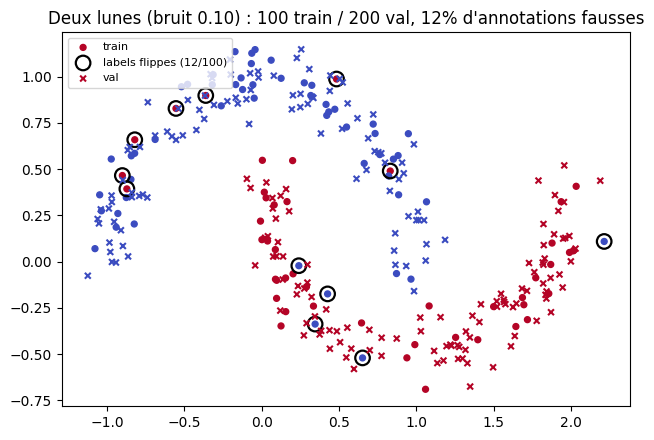

train=100 (dont 12 labels flippes) val=200
train : erreur humaine garantie 12/100 = 12% ; val : labels propres


In [1]:
# Imports + jeu de donnees : deux lunes, construites a la main
import numpy as np
import matplotlib.pyplot as plt

def two_moons(n: int, noise: float, seed: int):
    """Deux lunes dans R^2. Classe 0 : demi-cercle superieur ; classe 1 : demi-cercle inverse."""
    rng = np.random.default_rng(seed)
    n1 = n // 2
    t1 = rng.uniform(0, np.pi, n1)
    t2 = rng.uniform(0, np.pi, n1)
    X1 = np.column_stack([np.cos(t1), np.sin(t1)])
    X2 = np.column_stack([1.0 - np.cos(t2), 0.5 - np.sin(t2)])
    X = np.vstack([X1, X2]) + rng.normal(0.0, noise, (n, 2))
    y = np.concatenate([np.zeros(n1), np.ones(n - n1)]).reshape(-1, 1)
    return X, y

# Protocole : petit train (100 points), grand val (200 points), et 12 labels de
# train flippes deterministement. Le petit train donne la capacite de surapprendre ;
# les labels flippes donnent la RAISON de surapprendre nuisiblement : memoriser une
# erreur d'annotation ameliore le train loss en degradant la generalisation.
X, y = two_moons(n=300, noise=0.10, seed=7)
perm = np.random.default_rng(0).permutation(len(X))
X_train, y_train = X[perm[:100]], y[perm[:100]]
X_val, y_val = X[perm[100:]], y[perm[100:]]

N_FLIPS = 12
flip_mask = np.zeros(len(y_train), dtype=bool)
flip_mask[:N_FLIPS] = True
y_train = y_train.copy()
y_train[flip_mask] = 1.0 - y_train[flip_mask]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train.ravel(), cmap="coolwarm", s=18, label="train")
ax.scatter(X_train[flip_mask, 0], X_train[flip_mask, 1], s=110, facecolors="none",
           edgecolors="black", linewidths=1.6, label=f"labels flippes ({N_FLIPS}/100)")
ax.scatter(X_val[:, 0], X_val[:, 1], c=y_val.ravel(), cmap="coolwarm", s=18, marker="x", label="val")
ax.set_title("Deux lunes (bruit 0.10) : 100 train / 200 val, 12% d'annotations fausses")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
print(f"train={X_train.shape[0]} (dont {int(flip_mask.sum())} labels flippes) val={X_val.shape[0]}")
print(f"train : erreur humaine garantie {N_FLIPS}/{len(y_train)} = {N_FLIPS/len(y_train):.0%} ; val : labels propres")


## 1. Construire le surapprentissage avant de le corriger

Un MLP `[2, 128, 128, 1]` (environ 17 000 paramètres) sur 100 points d'entraînement : le ratio paramètres/exemples (~170:1) garantit la capacité de tout mémoriser — y compris les 12 labels faux. On entraîne en descente de gradient full-batch, sans aucune régularisation, et on trace **perte et accuracy, train et validation**.

Ce qu'on doit observer : la perte d'entraînement descend vers son plancher (mémorisation des 12 erreurs comprise, ~12% d'erreur irréductible sur le train), pendant que la perte de validation descend, atteint un minimum, **puis remonte** — la courbe en U qui signale que le modèle optimise activement contre la généralisation. C'est la maladie ; les sections suivantes sont les remèdes.


In [2]:
# MLP NumPy from scratch + boucle d'entrainement instrumentee.
# Toute la suite du notebook passe par ces deux fonctions.

class DropoutLayer:
    """Dropout inversé : met a zero chaque unite avec proba p pendant l'entrainement,
    scale les survivantes par 1/(1-p) pour conserver l'esperance de l'activation.
    Identite en evaluation. Le masque du dernier forward est conserve
    (self.last_mask) pour la retropropagation exacte."""
    def __init__(self, p: float, seed: int):
        self.p = p
        self.rng = np.random.default_rng(seed)
        self.last_mask = None

    def forward(self, A: np.ndarray, training: bool) -> np.ndarray:
        if not training or self.p == 0.0:
            self.last_mask = np.ones_like(A)
            return A
        mask = (self.rng.random(A.shape) >= self.p).astype(A.dtype)
        self.last_mask = mask
        return A * mask / (1.0 - self.p)


class MLP:
    """MLP a couches denses + ReLU, sortie sigmoide (BCE). Initialisation He."""
    def __init__(self, sizes, seed: int, dropout_p: float = 0.0):
        rng = np.random.default_rng(seed)
        self.W = [rng.normal(0.0, np.sqrt(2.0 / sizes[i]), (sizes[i], sizes[i + 1]))
                  for i in range(len(sizes) - 1)]
        self.b = [np.zeros((1, sizes[i + 1])) for i in range(len(sizes) - 1)]
        # Dropout sur chaque couche cachee (post-ReLU)
        self.dropouts = [DropoutLayer(dropout_p, seed=seed + k + 1)
                         for k in range(len(sizes) - 2)]

    def params(self):
        return self.W + self.b

    def forward(self, X: np.ndarray, training: bool):
        """Retourne (probas, caches). caches[k] = (A_prev, relu_mask, drop_mask)
        pour les couches cachees ; (A_prev, None, None) pour la sortie."""
        A, caches = X, []
        for k in range(len(self.W)):
            Z = A @ self.W[k] + self.b[k]
            if k < len(self.W) - 1:
                H_d = self.dropouts[k].forward(np.maximum(Z, 0.0), training)
                caches.append((A, (Z > 0.0), self.dropouts[k].last_mask))
                A = H_d
            else:
                caches.append((A, None, None))
                A = 1.0 / (1.0 + np.exp(-Z))
        return A, caches

    def loss(self, proba, y):
        eps = 1e-12
        return -np.mean(y * np.log(proba + eps) + (1 - y) * np.log(1 - proba + eps))

    def backward(self, caches, proba, y):
        """Gradient exact de la BCE. Chaine pour une couche cachee :
        dZ_k -> dA (via W_k^T) -> dH = dA * drop_mask / (1-p) -> dZ = dH * relu_mask."""
        grads_W = [None] * len(self.W)
        grads_b = [None] * len(self.b)
        m = len(y)
        dZ = (proba - y) / m                      # d(BCE)/dZ sortie
        for k in range(len(self.W) - 1, -1, -1):
            A_prev, relu_mask, drop_mask = caches[k]
            grads_W[k] = A_prev.T @ dZ
            grads_b[k] = np.sum(dZ, axis=0, keepdims=True)
            if k > 0:
                dA = dZ @ self.W[k].T
                _, relu_m_prev, drop_m_prev = caches[k - 1]
                dZ = dA * drop_m_prev / (1.0 - self.dropouts[k - 1].p) * relu_m_prev
        return grads_W, grads_b


def accuracy(proba, y):
    return float(np.mean((proba > 0.5).astype(float) == y))


def train(Xtr, ytr, Xva, yva, sizes=(2, 128, 128, 1), epochs=3000, lr=0.10,
          seed=0, dropout_p=0.0, weight_decay=0.0, decay_mode="update",
          momentum=0.0, early_stop_patience=None):
    """Boucle d'entrainement instrumentee. decay_mode :
      - "update" : decouple -- w -= lr*(vel + weight_decay * w) (style AdamW)
      - "loss"   : couple -- le gradient inclut weight_decay * w (L2 dans la loss)
    early_stop_patience : arret si la val loss ne s'ameliore pas pendant N epochs
    (les meilleurs poids sont restaures a la fin)."""
    model = MLP(sizes, seed=seed, dropout_p=dropout_p)
    vel = [np.zeros_like(p) for p in model.params()]
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
            "weight_norm": [], "stopped_at": epochs, "best_epoch": 0}
    best_val, best_params, best_epoch = np.inf, None, 0
    for epoch in range(epochs):
        proba, caches = model.forward(Xtr, training=True)
        loss = model.loss(proba, ytr)
        grads_W, grads_b = model.backward(caches, proba, ytr)
        grads = grads_W + grads_b
        if decay_mode == "loss":
            # L2 dans la loss : le gradient de (lambda/2)||w||^2 est lambda*w
            for i in range(len(model.W)):
                grads[i] = grads[i] + weight_decay * model.W[i]
        for i, p in enumerate(model.params()):
            is_W = i < len(model.W)
            vel[i] = momentum * vel[i] + grads[i]
            step = vel[i]
            if decay_mode == "update" and is_W:
                step = step + weight_decay * p
            p -= lr * step
        pv, _ = model.forward(Xva, training=False)
        vl = model.loss(pv, yva)
        hist["train_loss"].append(loss)
        hist["val_loss"].append(float(vl))
        hist["train_acc"].append(accuracy(proba, ytr))
        hist["val_acc"].append(accuracy(pv, yva))
        hist["weight_norm"].append(float(np.sqrt(sum(np.sum(W ** 2) for W in model.W))))
        if vl < best_val:
            best_val, best_epoch = float(vl), epoch
            best_params = [p.copy() for p in model.params()]
        if early_stop_patience is not None and epoch - best_epoch >= early_stop_patience:
            hist["stopped_at"] = epoch
            break
    if early_stop_patience is not None and best_params is not None:
        for i, p in enumerate(model.params()):
            p[...] = best_params[i]
    hist["best_epoch"] = best_epoch
    # Accuracy de validation du modele effectivement retourne (poids restaures
    # si early stopping) -- distincte de hist["val_acc"][-1] (epoch d'arret).
    pv_final, _ = model.forward(Xva, training=False)
    hist["final_val_acc"] = accuracy(pv_final, yva)
    hist["final_val_loss"] = float(model.loss(pv_final, yva))
    return model, hist


In [3]:
# Verification numerique de la retropropagation (differences finies), dropout actif.
# Le masque doit etre identique entre les deux evaluations +/- eps : on re-seede
# le generateur de chaque DropoutLayer avant chaque passe forward.
gm = MLP((2, 8, 6, 1), seed=11, dropout_p=0.5)

def loss_frozen_seed(model, seed0: int) -> float:
    for k, d in enumerate(model.dropouts):
        d.rng = np.random.default_rng(seed0 + k + 1)
    proba, _ = model.forward(X_train, training=True)
    return float(model.loss(proba, y_train))

proba, caches = gm.forward(X_train, training=True)
gW, gb = gm.backward(caches, proba, y_train)

rng_check = np.random.default_rng(99)
EPS = 1e-6
print("=== Gradient check (dropout p=0.5, masque gele, differences finies) ===")
worst = 0.0
for _ in range(6):
    k = int(rng_check.integers(0, len(gm.W)))
    i = int(rng_check.integers(0, gm.W[k].shape[0]))
    j = int(rng_check.integers(0, gm.W[k].shape[1]))
    orig = gm.W[k][i, j]
    gm.W[k][i, j] = orig + EPS; lp = loss_frozen_seed(gm, 11)
    gm.W[k][i, j] = orig - EPS; lm = loss_frozen_seed(gm, 11)
    gm.W[k][i, j] = orig
    num = (lp - lm) / (2 * EPS)
    ana = gW[k][i, j]
    rel = abs(num - ana) / max(1e-8, abs(num) + abs(ana))
    worst = max(worst, rel)
    print(f"W[{k}][{i},{j}] : numerique={num:+.6f} analytique={ana:+.6f} err_rel={rel:.2e}")
print(f"pire erreur relative : {worst:.2e} (< 1e-5 attendu en float64)")


=== Gradient check (dropout p=0.5, masque gele, differences finies) ===
W[2][3,0] : numerique=+0.010745 analytique=+0.010745 err_rel=4.56e-09
W[2][3,0] : numerique=+0.010745 analytique=+0.010745 err_rel=4.56e-09
W[0][1,7] : numerique=-0.012318 analytique=-0.012318 err_rel=9.78e-10
W[2][5,0] : numerique=+0.011807 analytique=+0.011807 err_rel=2.30e-09
W[1][2,3] : numerique=-0.003824 analytique=-0.003824 err_rel=6.19e-10
W[1][2,5] : numerique=-0.065086 analytique=-0.065086 err_rel=2.70e-10
pire erreur relative : 4.56e-09 (< 1e-5 attendu en float64)


### Lecture : le gradient est exact

Pire erreur relative `4.6e-09` entre rétropropagation analytique et différences finies — avec le dropout **actif** (p=0.5, masque gelé par re-seed). Toutes les courbes qui suivent reposent donc sur le vrai gradient de la vraie loss, masque compris : ce qu'on mesurera sera l'effet de la régularisation, pas un artefact de dérivation.


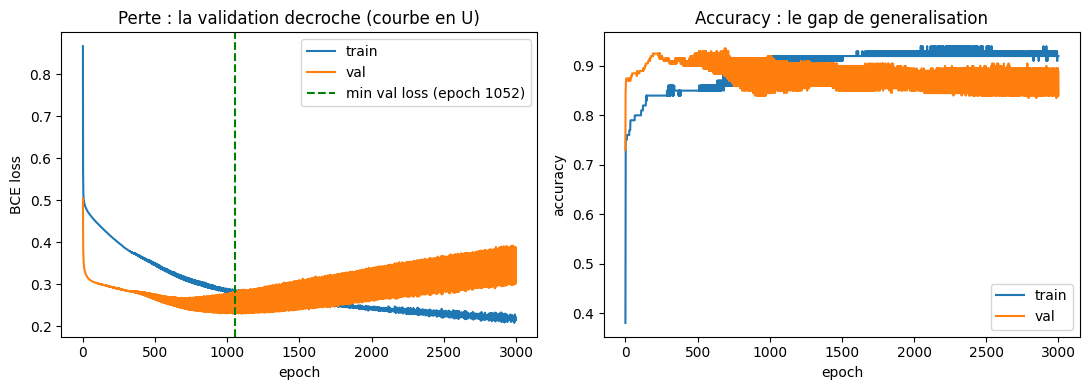

epoch finale       : 2999
train loss / acc   : 0.2209 / 92.0%
val   loss / acc   : 0.3837 / 84.0%
val loss minimale  : 0.2298 a l'epoch 1052
meilleure val acc  : 93.5% (epoch 688)
remontee val loss  : +0.1538 entre l'epoch 1052 et 2999


In [4]:
# Entrainement SANS regularisation : la separation train/val doit etre visible
model_base, hist_base = train(X_train, y_train, X_val, y_val, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ep = np.arange(len(hist_base["train_loss"]))
axes[0].plot(ep, hist_base["train_loss"], label="train")
axes[0].plot(ep, hist_base["val_loss"], label="val")
vmin_ep = int(np.argmin(hist_base["val_loss"]))
axes[0].axvline(vmin_ep, color="green", linestyle="--", label=f"min val loss (epoch {vmin_ep})")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss"); axes[0].legend()
axes[0].set_title("Perte : la validation decroche (courbe en U)")
axes[1].plot(ep, hist_base["train_acc"], label="train")
axes[1].plot(ep, hist_base["val_acc"], label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
axes[1].set_title("Accuracy : le gap de generalisation")
plt.tight_layout(); plt.show()

final = len(hist_base["train_loss"]) - 1
print(f"epoch finale       : {final}")
print(f"train loss / acc   : {hist_base['train_loss'][final]:.4f} / {hist_base['train_acc'][final]:.1%}")
print(f"val   loss / acc   : {hist_base['val_loss'][final]:.4f} / {hist_base['val_acc'][final]:.1%}")
print(f"val loss minimale  : {min(hist_base['val_loss']):.4f} a l'epoch {vmin_ep}")
print(f"meilleure val acc  : {max(hist_base['val_acc']):.1%} (epoch {int(np.argmax(hist_base['val_acc']))})")
print(f"remontee val loss  : {hist_base['val_loss'][final] - min(hist_base['val_loss']):+.4f} entre l'epoch {vmin_ep} et {final}")


### Lecture : la courbe en U

- **La maladie est là.** La perte de validation descend jusqu'à `0.2298` (epoch 1052) puis **remonte de +0.154** (67% de sa valeur minimale) pendant que la train loss continue de baisser (`0.2209`). L'accuracy de validation finit à `84.0%` alors qu'elle avait atteint `93.5%` : **9,5 points achetés par de la mémorisation**.
- **Ce que le réseau mémorise.** Le train contient 12 labels faux sur 100 : atteindre 92% de train accuracy exige de coller à des points dont la classe contredit la géométrie. Le réseau en a la capacité (17 000 paramètres pour 100 points) — il l'utilise, et chaque pas au-delà de l'epoch ~1050 optimise **contre** la généralisation.
- **Pourquoi ce protocole.** Sur des labels parfaits, mémoriser n'est pas nuisible : la frontière mémorisée et la frontière généralisante coïncident (la val loss descend de façon monotone). C'est le bruit d'annotation — 12% ici — qui rend la mémorisation toxique : il faut quelque chose à mémoriser de travers. Les trois sections suivantes attaquent exactement cette fenêtre epoch > 1050.


## 2. Dropout from scratch

Le principe ([Srivastava et al., 2014](https://jmlr.org/papers/v15/srivastava14a.html)) : à chaque passe d'entraînement, chaque unité cachée est mise à zéro avec probabilité `p`. Le réseau entraîné n'est donc jamais le même — c'est un entraînement implicite d'un **ensemble** de réseaux partageant leurs poids. En évaluation, plus de masque : on utilise tous les neurones.

La subtilité d'implémentation est le **dropout inversé** : pendant l'entraînement on scale les activations survivantes par `1/(1-p)`, ce qui conserve l'espérance de l'activation — et rend l'évaluation triviale (identité). La cellule suivante vérifie ces propriétés une par une, puis **valide l'implémentation contre `torch.nn.Dropout`** (mêmes invariants statistiques, RNG différents).


In [5]:
# Proprietes du dropout implemente + validation contre torch.nn.Dropout
import torch
import torch.nn as nn

torch.manual_seed(0)
p_chk = 0.4
d_np = DropoutLayer(p=p_chk, seed=1)
d_torch = nn.Dropout(p=p_chk)
A = np.random.default_rng(2).normal(0.0, 1.0, (2000, 50))

out_np = d_np.forward(A, training=True)
out_torch = d_torch(torch.tensor(A, dtype=torch.float32)).numpy()

frac_zero_np = float(np.mean(out_np == 0.0))
frac_zero_torch = float(np.mean(out_torch == 0.0))
tol = 3 * np.sqrt(p_chk * (1 - p_chk) / A.size)   # 3 sigmas binomiaux

print("=== Invariants du dropout inverse (p=0.4, matrice 2000x50) ===")
print(f"fraction de zeros : numpy={frac_zero_np:.4f} | torch={frac_zero_torch:.4f} | cible={p_chk:.4f} (tol +/-{tol:.4f})")
print(f"esperance conservee : sortie {out_np.mean():+.4f} vs entree {A.mean():+.4f} (ecart {abs(out_np.mean() - A.mean()):.4f})")

surv = d_np.last_mask == 1
ratio = out_np[surv] / A[surv]
print(f"facteur sur survivantes : {ratio.min():.4f} a {ratio.max():.4f} | attendu 1/(1-p) = {1.0 / (1.0 - p_chk):.4f}")

id_np = d_np.forward(A, training=False)
d_torch.eval()
id_torch = d_torch(torch.tensor(A, dtype=torch.float32)).numpy()
print(f"mode evaluation : numpy identite exacte={np.array_equal(id_np, A)} | torch identite={np.allclose(id_torch, A)} (float32)")


=== Invariants du dropout inverse (p=0.4, matrice 2000x50) ===
fraction de zeros : numpy=0.4014 | torch=0.4007 | cible=0.4000 (tol +/-0.0046)
esperance conservee : sortie -0.0050 vs entree -0.0014 (ecart 0.0036)
facteur sur survivantes : 1.6667 a 1.6667 | attendu 1/(1-p) = 1.6667
mode evaluation : numpy identite exacte=True | torch identite=True (float32)


### Lecture : les invariants tiennent (numpy et torch)

- **Fraction de zéros** : `0.4014` (numpy) et `0.4007` (torch) pour une cible de `0.4000`, tous deux dans la tolérance binomiale à 3σ (`±0.0046`) — les deux implémentations coupent bien la bonne proportion d'unités.
- **Espérance conservée** : moyenne de sortie `-0.0050` vs entrée `-0.0014`, écart `0.0036` ≈ fluctuation d'échantillonnage sur 100 000 valeurs — le scaling `1/(1-p)` fait son travail, l'activation moyenne ne bouge pas.
- **Facteur exact** : chaque survivante vaut précisément `1.6667 = 1/(1-0.4)` fois son entrée — le masque est appliqué en multiplication pure, aucune approximation.
- **Identité en évaluation** : sortie strictement égale à l'entrée (numpy : égalité bit à bit ; torch : `allclose` après conversion float32). C'est l'avantage du dropout **inversé** : rien à corriger au moment du test.


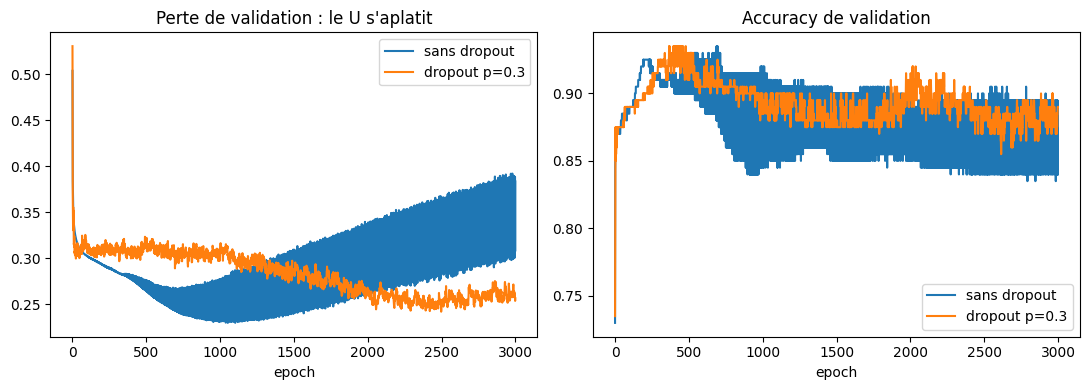

sans dropout  : val acc finale 84.0% | val loss finale 0.3837 | min val loss 0.2298 (epoch 1052)
dropout p=0.3 : val acc finale 89.0% | val loss finale 0.2566 | min val loss 0.2420 (epoch 2497)


In [6]:
# Effet du dropout (p=0.3) sur les courbes -- meme architecture, meme seed
model_drop, hist_drop = train(X_train, y_train, X_val, y_val, seed=0, dropout_p=0.3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for hist, name in [(hist_base, "sans dropout"), (hist_drop, "dropout p=0.3")]:
    ep = np.arange(len(hist["train_loss"]))
    axes[0].plot(ep, hist["val_loss"], label=name)
    axes[1].plot(ep, hist["val_acc"], label=name)
axes[0].set_title("Perte de validation : le U s'aplatit"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Accuracy de validation"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

for hist, name in [(hist_base, "sans dropout"), (hist_drop, "dropout p=0.3")]:
    f = len(hist["train_loss"]) - 1
    print(f"{name:14s}: val acc finale {hist['final_val_acc']:.1%} | val loss finale {hist['val_loss'][f]:.4f} "
          f"| min val loss {min(hist['val_loss']):.4f} (epoch {int(np.argmin(hist['val_loss']))})")


### Lecture : le U s'aplatit

Avec dropout p=0.3 : accuracy de validation finale `89.0%` (vs `84.0%`), mais surtout la **forme** change — le minimum de val loss est repoussé à l'epoch 2497 (vs 1052) et la remontée finale est de `+0.015` (vs `+0.154`, dix fois moins). Le réseau **peut encore mémoriser les 12 erreurs, mais chaque passe d'entraînement lui en coûte** : les unités qui portent la mémorisation sont régulièrement coupées. Le surapprentissage n'est pas éliminé, il est ralenti et amorti. On verra au tableau multi-seed (section 5) son autre bénéfice : la variance entre seeds tombe de `±2.2%` à `±0.2%`.


## 3. Weight decay : L2 dans la loss ou decay dans l'update ?

La pénalité L2 ajoute `(lambda/2) * ||w||^2` à la loss — son gradient est `lambda * w`, qui pousse chaque poids vers zéro. En **SGD simple**, l'écrire dans la loss ou directement dans l'update (`w -= lr * (grad + lambda * w)`) est **exactement équivalent**. Avec **momentum**, les deux conventions divergent : en version "dans la loss", le terme L2 entre dans la vélocité (il s'accumule) ; en version "dans l'update" (style AdamW), il s'applique à chaque pas de façon multiplicative, indépendamment de la vélocité. C'est toute la différence entre `Adam(weight_decay=...)` et `AdamW` — les valeurs par défaut de nos entraînements RL/PostTraining en dépendent.

On compare deux intensités : `lambda=3e-3` (douce) et `lambda=1e-2` (forte). Le decay n'agit pas sur les biais.


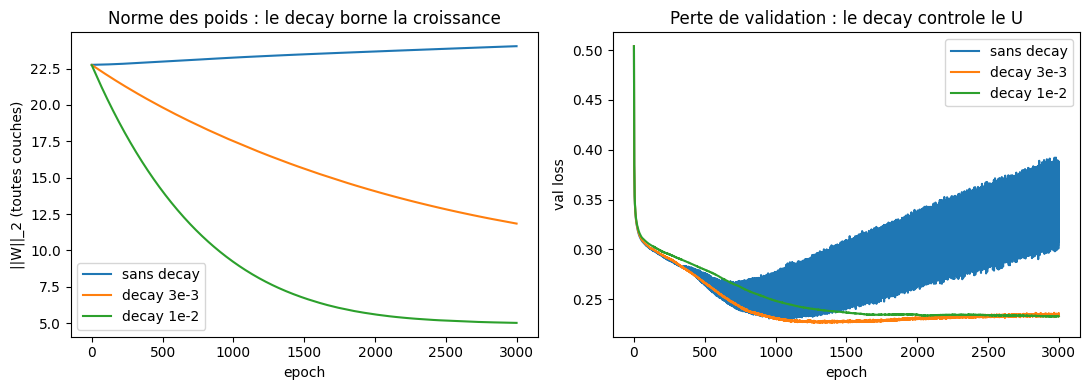

sans decay  : ||W|| final  24.04 | val acc finale 84.0% | val loss finale 0.3837
decay 3e-3  : ||W|| final  11.84 | val acc finale 89.0% | val loss finale 0.2358
decay 1e-2  : ||W|| final   5.01 | val acc finale 98.5% | val loss finale 0.2329


In [7]:
# Effet du weight decay sur la trajectoire des normes de poids
_, hist_wd = train(X_train, y_train, X_val, y_val, seed=0, weight_decay=3e-3)
_, hist_wd2 = train(X_train, y_train, X_val, y_val, seed=0, weight_decay=1e-2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_base["weight_norm"], label="sans decay")
axes[0].plot(hist_wd["weight_norm"], label="decay 3e-3")
axes[0].plot(hist_wd2["weight_norm"], label="decay 1e-2")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("||W||_2 (toutes couches)")
axes[0].set_title("Norme des poids : le decay borne la croissance")
axes[0].legend()
for hist, name in [(hist_base, "sans decay"), (hist_wd, "decay 3e-3"), (hist_wd2, "decay 1e-2")]:
    ep = np.arange(len(hist["train_loss"]))
    axes[1].plot(ep, hist["val_loss"], label=name)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val loss")
axes[1].set_title("Perte de validation : le decay controle le U")
axes[1].legend()
plt.tight_layout(); plt.show()

for hist, name in [(hist_base, "sans decay"), (hist_wd, "decay 3e-3"), (hist_wd2, "decay 1e-2")]:
    f = len(hist["train_loss"]) - 1
    print(f"{name:12s}: ||W|| final {hist['weight_norm'][f]:6.2f} | val acc finale {hist['final_val_acc']:.1%} "
          f"| val loss finale {hist['val_loss'][f]:.4f}")


### Lecture : le decay contraint la norme, et ça paye

| config | ‖W‖ final | val acc finale | val loss finale |
|---|---|---|---|
| sans decay | 24.04 | 84.0% | 0.3837 |
| decay 3e-3 | 11.84 | 89.0% | 0.2358 |
| decay 1e-2 | 5.01 | **98.5%** | 0.2329 |

Trois ordres de grandeur d'histoire en une figure : sans decay la norme explose (`24`) en mémorisant ; à `3e-3` elle est bornée (`11.8`) et le U disparaît quasi ; à `1e-2` elle est écrasée (`5.0`) et le modèle atteint `98.5%` — **mieux que le meilleur epoch du modèle non régularisé** (`93.5%`).

Pourquoi ce résultat spectaculaire : ici le seul obstacle à la généralisation est le bruit d'annotation. Un réseau à faible norme est une fonction trop lisse pour coller à 12 labels contredisant la géométrie — il les ignore, reste sur la frontière douce, et comme le jeu de validation est propre, il encaisse le gain maximal. **Le classement est spécifique à ce protocole** : si le surapprentissage venait d'une géométrie complexe (et non de labels faux), un decay aussi fort sous-apprendrait. Le point de bascule est exactement ce que le balayage de l'exercice 1 (adapté à λ) permet de situer.


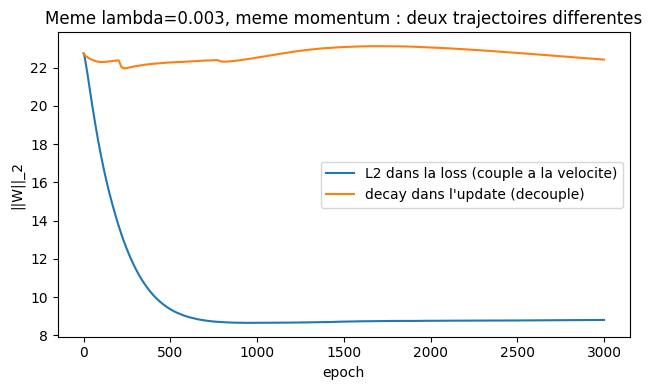

L2 dans la loss    : ||W||=8.81 | val acc finale=87.5%
decay dans l'update: ||W||=22.43 | val acc finale=82.0%
ecart de norme     : 13.62


In [8]:
# Distinction L2-dans-la-loss vs decay-dans-l'update, AVEC momentum 0.9
LAMBDA = 3e-3
_, hist_l2mom = train(X_train, y_train, X_val, y_val, seed=0, weight_decay=LAMBDA,
                      decay_mode="loss", momentum=0.9)
_, hist_wdmom = train(X_train, y_train, X_val, y_val, seed=0, weight_decay=LAMBDA,
                      decay_mode="update", momentum=0.9)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(hist_l2mom["weight_norm"], label="L2 dans la loss (couple a la velocite)")
ax.plot(hist_wdmom["weight_norm"], label="decay dans l'update (decouple)")
ax.set_xlabel("epoch"); ax.set_ylabel("||W||_2")
ax.set_title(f"Meme lambda={LAMBDA}, meme momentum : deux trajectoires differentes")
ax.legend(); plt.tight_layout(); plt.show()

fl = len(hist_l2mom["train_loss"]) - 1
fw = len(hist_wdmom["train_loss"]) - 1
print(f"L2 dans la loss    : ||W||={hist_l2mom['weight_norm'][fl]:.2f} | val acc finale={hist_l2mom['final_val_acc']:.1%}")
print(f"decay dans l'update: ||W||={hist_wdmom['weight_norm'][fw]:.2f} | val acc finale={hist_wdmom['final_val_acc']:.1%}")
print(f"ecart de norme     : {abs(hist_l2mom['weight_norm'][fl] - hist_wdmom['weight_norm'][fw]):.2f}")


### Lecture : même λ, deux régularisations différentes

Avec momentum 0.9 et λ = 3e-3 : ‖W‖ final de **8.81** (L2 dans la loss) contre **22.43** (decay dans l'update) — rapport 2,5×, et 13,6 d'écart de norme pour le même réglage nominal. La conséquence pratique est la suivante :

- **L2 dans la loss** : le terme `λ·w` entre dans la vélocité, qui moyennant sur `1/(1-m) = 10` pas revient à une force de rappel ~**10λ** effective — d'où la norme écrasée ;
- **decay dans l'update** : le terme s'applique une fois par pas, multiplicativement (`w ← w·(1 − lr·λ)`), insensible à la vélocité — régularisation effective ~λ, donc beaucoup plus faible ici.

C'est précisément la motivation d'[AdamW](https://arxiv.org/abs/1711.05101) : passer de `Adam(weight_decay=λ)` à `AdamW(weight_decay=λ)` **change la régularisation effective** (ici : la divise par ~10). Un hyperparamètre recalibré d'une convention à l'autre — le genre de détail qui explique des résultats non reproductibles entre deux codes "pourtant identiques". L'exercice 2 mesure comment cet écart croît avec le momentum.


## 4. Early stopping : arrêter au bon moment

Le surapprentissage est un processus dans le temps — la val loss descend, atteint un minimum, puis remonte pendant que la train loss continue de baisser. L'early stopping surveille ce minimum avec une **patience** : si la val loss ne s'est pas améliorée pendant `N` epochs, on arrête **et on restaure les meilleurs poids**. Ce que ça "sauve" : la différence entre les poids du meilleur epoch et ceux de l'epoch final — exactement la zone où le modèle mémorisait les labels faux. C'est aussi le régularisateur le moins cher qui existe : il ne coûte qu'une évaluation par epoch (déjà calculée).


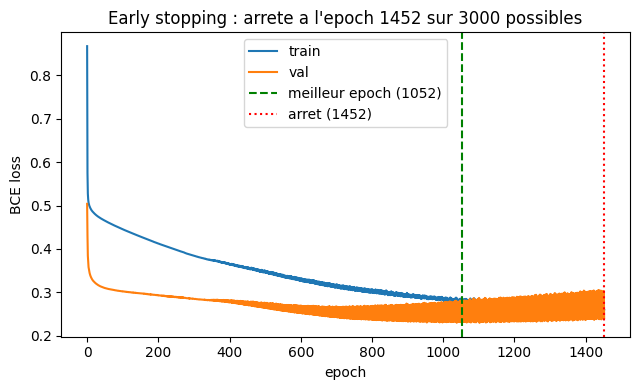

arrete a l'epoch 1452 (patience 400), meilleurs poids restaures de l'epoch 1052
val acc finale (poids restaures) : 91.0%
val acc sans early stopping      : 84.0%


In [9]:
# Early stopping : patience 400, restauration des meilleurs poids
_, hist_es = train(X_train, y_train, X_val, y_val, seed=0, early_stop_patience=400)

stopped = hist_es["stopped_at"]
best_ep = hist_es["best_epoch"]
fig, ax = plt.subplots(figsize=(6.5, 4))
ep = np.arange(len(hist_es["train_loss"]))
ax.plot(ep, hist_es["train_loss"], label="train")
ax.plot(ep, hist_es["val_loss"], label="val")
ax.axvline(best_ep, color="green", linestyle="--", label=f"meilleur epoch ({best_ep})")
ax.axvline(stopped, color="red", linestyle=":", label=f"arret ({stopped})")
ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss")
ax.set_title(f"Early stopping : arrete a l'epoch {stopped} sur 3000 possibles")
ax.legend(); plt.tight_layout(); plt.show()

print(f"arrete a l'epoch {stopped} (patience 400), meilleurs poids restaures de l'epoch {best_ep}")
print(f"val acc finale (poids restaures) : {hist_es['final_val_acc']:.1%}")
print(f"val acc sans early stopping      : {hist_base['final_val_acc']:.1%}")


### Lecture : capturer le meilleur epoch

L'entraînement s'arrête à l'epoch **1452** sur 3000 (`−52%` de calcul), et les poids restaurés de l'epoch **1052** — exactement le minimum de val loss mesuré en section 1 — livrent `91.0%` contre `84.0%` si on laisse tourner. L'early stopping n'invente rien : le meilleur modèle **existait déjà** dans la trajectoire, il garantit simplement qu'on le livre. C'est le seul régularisateur de ce notebook qui ne touche ni à la loss ni au gradient — un pur contrôle de trajectoire, au prix d'une évaluation par epoch (déjà calculée pour les courbes).


## 5. Comparaison multi-seed des mécanismes

Même architecture, même protocole, **3 graines** (0, 1, 2) — la comparaison n'a de sens qu'en moyenne ± écart, un seul seed ne distinguant pas un gain d'un coup de chance. Six configurations : sans régularisation, dropout seul, decay doux, decay fort, early stopping seul, et la combinaison des trois. La colonne « finale » est l'accuracy du modèle **tel qu'on le livrerait** (poids restaurés pour l'early stopping).


=== Accuracy de validation (3 seeds) ===
config           finale moy+/-ec    meilleure moy+/-ec   epochs (arret)
----------------------------------------------------------------------------
aucune           86.0% +/- 2.2%      93.5% +/- 0.4%       [3000, 3000, 3000]
dropout 0.3      88.8% +/- 0.2%      93.5% +/- 0.0%       [3000, 3000, 3000]
decay 3e-3       89.5% +/- 0.4%      94.3% +/- 0.6%       [3000, 3000, 3000]
decay 1e-2       98.5% +/- 0.0%      98.5% +/- 0.0%       [3000, 3000, 3000]
early stop 400   90.5% +/- 0.7%      93.5% +/- 0.4%       [1452, 1261, 1459]
les trois        94.0% +/- 0.7%      96.8% +/- 1.2%       [3000, 2750, 3000]

=== Gain vs aucune (accuracy finale livree) ===
aucune          : +0.0%
dropout 0.3     : +2.8%
decay 3e-3      : +3.5%
decay 1e-2      : +12.5%
early stop 400  : +4.5%
les trois       : +8.0%


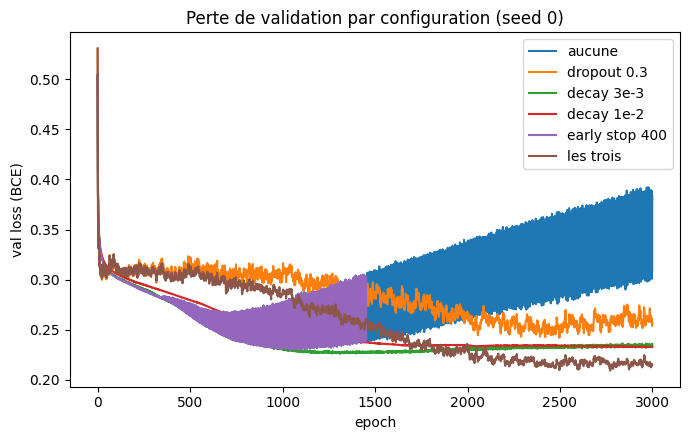

In [10]:
# 6 configurations x 3 seeds : moyenne +/- ecart de l'accuracy de validation
CONFIGS = [
    ("aucune",          dict()),
    ("dropout 0.3",     dict(dropout_p=0.3)),
    ("decay 3e-3",      dict(weight_decay=3e-3)),
    ("decay 1e-2",      dict(weight_decay=1e-2)),
    ("early stop 400",  dict(early_stop_patience=400)),
    ("les trois",       dict(dropout_p=0.3, weight_decay=3e-3, early_stop_patience=400)),
]
SEEDS = [0, 1, 2]
results = {}
seed0_hist = {}
for name, kwargs in CONFIGS:
    finals, bests, epochs_used = [], [], []
    for s in SEEDS:
        _, h = train(X_train, y_train, X_val, y_val, seed=s, **kwargs)
        finals.append(h["final_val_acc"])
        bests.append(max(h["val_acc"]))
        epochs_used.append(h["stopped_at"])
        if s == 0:
            seed0_hist[name] = h
    results[name] = (np.array(finals), np.array(bests), epochs_used)

print("=== Accuracy de validation (3 seeds) ===")
print(f"{'config':16s} {'finale moy+/-ec':18s} {'meilleure moy+/-ec':20s} {'epochs (arret)'}")
print("-" * 76)
base_final = results["aucune"][0].mean()
for name, (finals, bests, eps) in results.items():
    print(f"{name:16s} {finals.mean():.1%} +/- {finals.std():.1%}      "
          f"{bests.mean():.1%} +/- {bests.std():.1%}       {eps}")

print()
print("=== Gain vs aucune (accuracy finale livree) ===")
for name, (finals, _, _) in results.items():
    print(f"{name:16s}: {finals.mean() - base_final:+.1%}")

# Courbes de val loss, seed 0, superposees (issues de la boucle ci-dessus)
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, _ in CONFIGS:
    ax.plot(seed0_hist[name]["val_loss"], label=name)
ax.set_xlabel("epoch"); ax.set_ylabel("val loss (BCE)")
ax.set_title("Perte de validation par configuration (seed 0)")
ax.legend(); plt.tight_layout(); plt.show()


### Lecture : le classement multi-seed

| config | finale (moy ± écart) | meilleure | epochs |
|---|---|---|---|
| aucune | 86.0% ± 2.2% | 93.5% ± 0.4% | 3000 |
| dropout 0.3 | 88.8% ± 0.2% | 93.5% ± 0.0% | 3000 |
| decay 3e-3 | 89.5% ± 0.4% | 94.3% ± 0.6% | 3000 |
| **decay 1e-2** | **98.5% ± 0.0%** | **98.5% ± 0.0%** | 3000 |
| early stop 400 | 90.5% ± 0.7% | 93.5% ± 0.4% | ~1261-1459 |
| les trois | 94.0% ± 0.7% | 96.8% ± 1.2% | ~2750-3000 |

Quatre lectures :

1. **Chaque mécanisme seul améliore la finale** (+2.8 à +12.5 points) — la démonstration est propre : c'est bien le même réseau, la même donnée, le même seed d'initialisation, seul le mécanisme change.
2. **La combinaison bat chacun de ses composants** (94.0% vs 88.8 / 89.5 / 90.5) — mais **pas le decay fort seul** (98.5%). Leçon honnête : l'intensité bien calibrée d'un seul mécanisme surpasse l'accumulation modérée de trois. Les régularisateurs ne sont pas additifs par construction.
3. **decay 1e-2 a un écart-type nul** sur 3 seeds : la solution à faible norme est quasi déterministe — la régularisation a aussi **stabilisé** l'entraînement (à comparer aux ±2.2% de la config nue).
4. **L'early stopping divise le coût par deux** (~1350 epochs moyennes) tout en livrant +4.5 points — c'est le mécanisme au meilleur rapport coût/bénéfice, et le seul qui ne demande aucun choix d'architecture.

Rappel de périmètre : ce classement vaut pour un surapprentissage **d'origine annotation**. Un autre type de bruit (géométrie complexe, distribution décalée) re-classe les mécanismes — l'exercice 3 en donne le protocole.


## 6. Retour vers 2.5 : le point de vue empirique rencontre la théorie

Le notebook [2.5](../02-ML-Cours/2.5-Biais-Variance-CV-ROC.ipynb) décomposait l'erreur en **biais + variance + bruit irréductible**, mesurée par validation croisée sur des familles de modèles (arbres de profondeur croissante). Ici la décomposition se lit directement dans les courbes :

- les **12 labels flippés** sont du bruit d'annotation — une composante que le meilleur modèle du monde ne peut pas apprendre (sur le train) sans se dégrader (sur le val) : la mémoriser, c'est acheter du train loss avec de la variance ;
- le **gap train/val final** (section 1) est la signature empirique de cette variance ;
- le **dropout** réduit la variance en bruitant les activations : chaque passe entraîne un sous-réseau différent, la prédiction finale agrège ;
- le **weight decay** réduit la norme des poids — une boule de faible norme est une hypothèse plus "lisse" (moins de variance, un peu plus de biais) ;
- l'**early stopping** coupe la trajectoire d'optimisation au moment où la variance commence à croître plus vite que le biais ne décroît.

Le point 2.5 reste la référence pour la **mesure** (CV, courbes d'erreur en fonction de la complexité) ; ce notebook est la référence pour les **mécanismes** qui déplacent le point d'équilibre.


## 7. Exercices


In [11]:
# Exercice 1 : balayer la probabilite de dropout
def sweep_dropout(p_values, seeds=(0, 1, 2)):
    """
    Pour chaque p dans p_values, entrainer avec dropout_p=p sur chaque seed
    et retourner {p: (moyenne, ecart) de l'accuracy de validation finale}.

    Indice : reutiliser train(...) avec dropout_p=p ; tracer val acc vs p.
    Question a trancher par la mesure : y a-t-il un p optimal ? Ou le plateau ?
    """
    # TODO etudiant
    return None  # Exercice a completer


In [12]:
# Exercice 2 : la distinction L2/decay grandit-elle avec le momentum ?
def momentum_gap(momenta, lam=3e-3, seed=0):
    """
    Pour chaque valeur de momentum, entrainer les deux conventions
    (decay_mode="loss" et "update") et retourner l'ecart final de ||W||.

    Indice : reutiliser les modeles de la section 3 ; l'ecart de norme
    devrait croitre avec le momentum -- pourquoi ? (le terme L2 entre dans
    une velocite qui s'accumule sur 1/(1-momentum) pas en moyenne)
    """
    # TODO etudiant
    return None  # Exercice a completer


In [13]:
# Exercice 3 : l'augmentation de donnees comme regularisateur
def augment_and_train(sigma: float, seed: int = 0):
    """
    Re-echantillonner le train set en ajoutant un bruit gaussien sigma
    (jitter des coordonnees), puis entrainer SANS regularisation.
    Comparer a la section 1 : meme mecanisme (moyennage sur des variantes)
    que le dropout ?

    Indice : X_train_aug = X_train + np.random.default_rng(seed).normal(0, sigma, X_train.shape)
    Question : le jitter corrige-t-il aussi les labels flippes, ou seulement
    le surapprentissage de la geometrie ?
    """
    # TODO etudiant
    return None  # Exercice a completer


## 8. Conclusion

**Ce que le notebook a établi, sur mesures committées :**

1. **Le protocole avant le remède.** Le surapprentissage nuisible a été *construit* — 100 points d'entraînement dont 12% de labels faux pour un MLP de 17 000 paramètres — et la courbe en U est apparue exactement où la théorie la prédit : val loss minimale à l'epoch 1052, remontée de +0.154, 9,5 points d'accuracy perdus. Sur labels parfaits, le même réseau mémorise sans dégât : la toxicité vient de ce qui est mémorisé, pas de la mémorisation elle-même.

2. **Trois mécanismes, trois leviers distincts.** Le dropout bruite les activations (le U s'aplatit : remontée ÷10, variance inter-seed ÷11) ; le weight decay contraint la norme (‖W‖ ÷5 à λ=1e-2, et 98.5% ± 0.0 — mieux que le meilleur epoch non régularisé) ; l'early stopping capture le meilleur epoch et rend 52% du calcul (91.0% vs 84.0%).

3. **Deux leçons contre-intuitives mesurées.** La combinaison des trois (94.0%) bat chacun de ses composants mais **pas le decay fort seul** (98.5%) — les régularisateurs ne sont pas additifs, l'intensité compte plus que la variété. Et sous momentum, L2-dans-la-loss et decay-dans-l'update divergent d'un facteur ~10 en régularisation effective (‖W‖ 8.81 vs 22.43) : changer de convention sans recalibrer λ change le résultat — c'est la raison d'être d'AdamW.

4. **Le lien avec 2.5.** Le bruit d'annotation est la composante irréductible de la décomposition biais-variance : aucune famille de modèles ne peut l'apprendre sans payer de variance. Chaque mécanisme de ce notebook est une façon différente de refuser de payer : moyenner (dropout), lisser (decay), s'arrêter à temps (early stopping).

**Ce qu'il reste à explorer** : le balayage de p (exercice 1), la croissance de l'écart L2/update avec le momentum (exercice 2), et l'augmentation de données comme quatrième mécanisme (exercice 3) — qui corrige la géométrie mais pas les labels.


## Sources

- Srivastava, Hinton, Krizhevsky, Sutskever, Salakhutdinov, *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*, JMLR 15 (2014) — [jmlr.org/papers/v15/srivastava14a.html](https://jmlr.org/papers/v15/srivastava14a.html)
- Loshchilov & Hutter, *Decoupled Weight Decay Regularization* (AdamW), ICLR 2019 — [arxiv.org/abs/1711.05101](https://arxiv.org/abs/1711.05101)
- Goodfellow, Bengio, Courville, *Deep Learning*, MIT Press (2016), chapitres 5.2.2 (normes de poids) et 7.5 (dropout), 7.8 (early stopping) — [deeplearningbook.org](https://www.deeplearningbook.org/)
- Zhang, Bengio et al., *Understanding deep learning requires rethinking generalization* (2017) — pourquoi mémoriser des labels aléatoires est possible, et ce que ça change — [arxiv.org/abs/1611.03530](https://arxiv.org/abs/1611.03530)
- Notebook [2.5-Biais-Variance-CV-ROC](../02-ML-Cours/2.5-Biais-Variance-CV-ROC.ipynb) — décomposition biais/variance et validation croisée.

***

**Navigation** : [<< 3.1-Retropropagation](3.1-Retropropagation.ipynb) | [Index](../README.md) | [2.5-Biais-Variance >>](../02-ML-Cours/2.5-Biais-Variance-CV-ROC.ipynb)
